In [214]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import joblib

In [215]:
df = pd.read_csv('House price_predictionHousing.csv')

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [217]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

### EDA

In [218]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


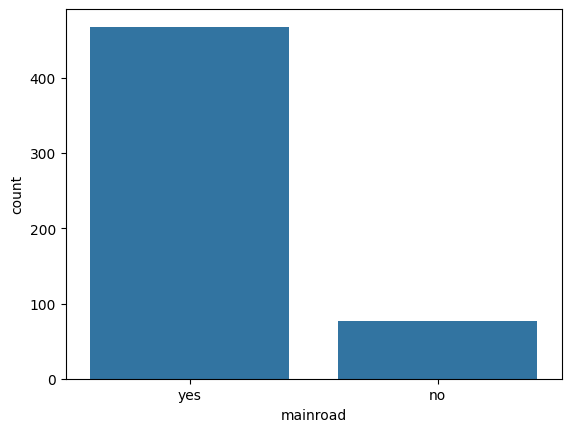

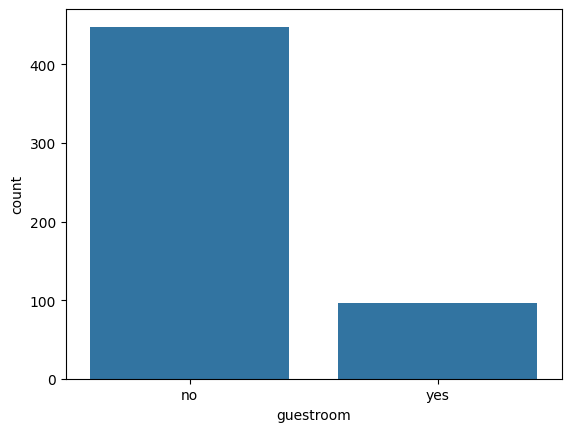

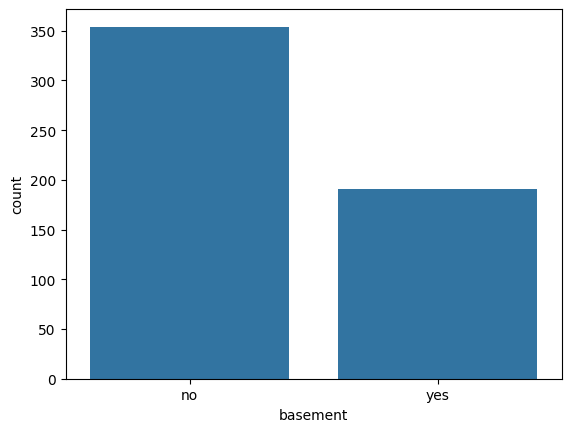

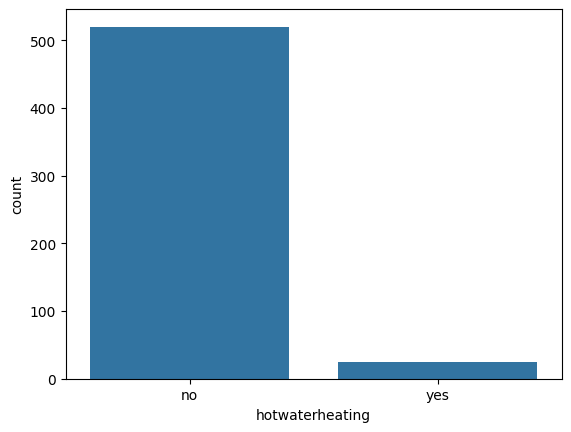

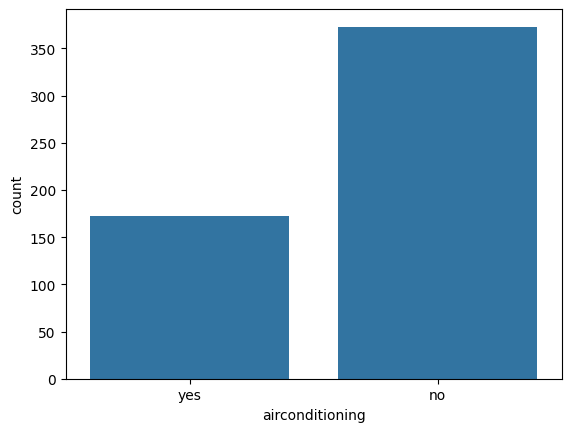

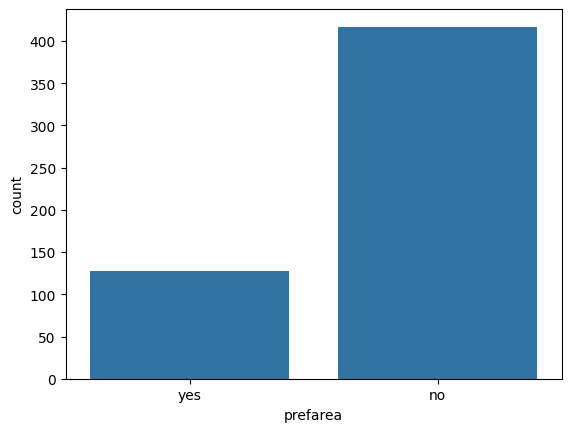

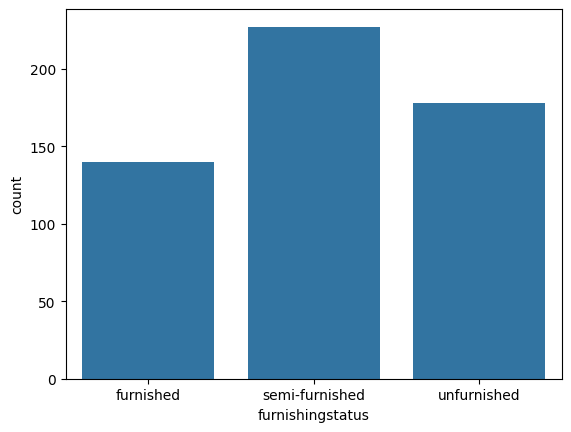

In [219]:
for i in df.select_dtypes(include='object').columns:
    sns.countplot(df,x=i)
    plt.show()

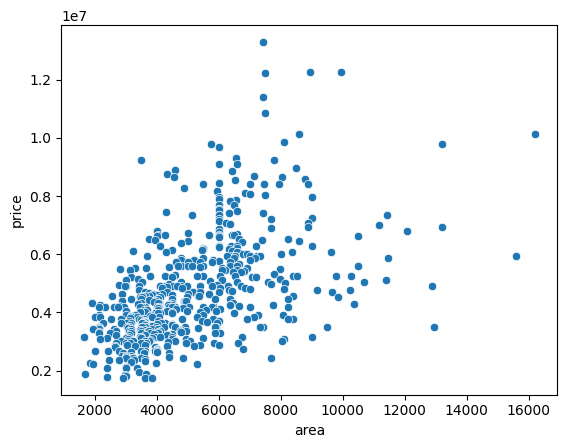

In [220]:
sns.scatterplot(data=df,x='area',y='price')
plt.show()

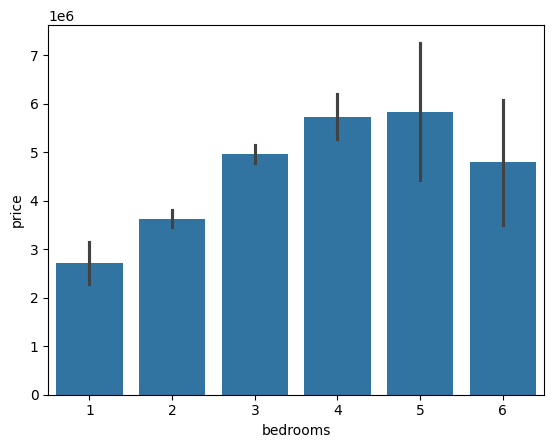

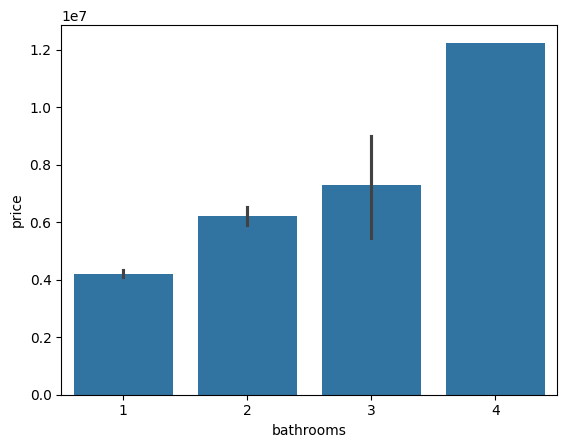

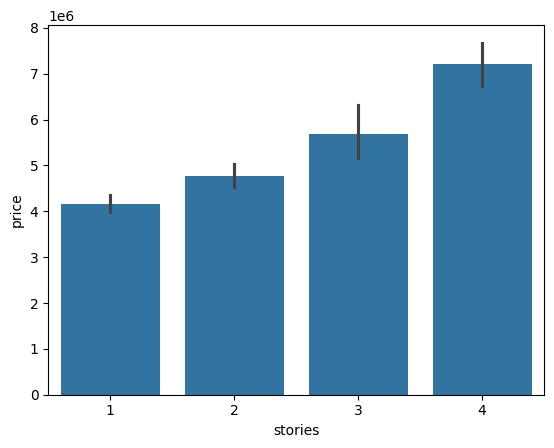

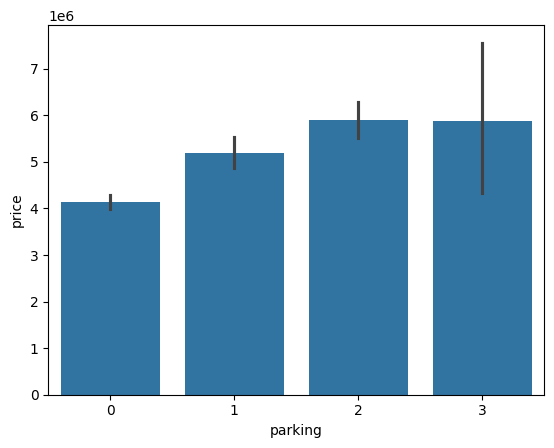

In [221]:
for i in ['bedrooms', 'bathrooms', 'stories', 'parking']:
    sns.barplot(data=df,x=i,y='price')
    plt.show()

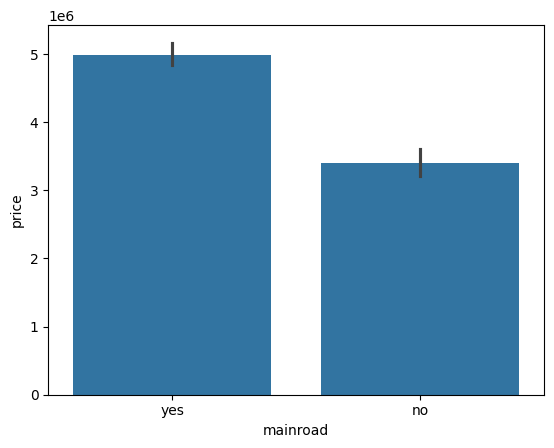

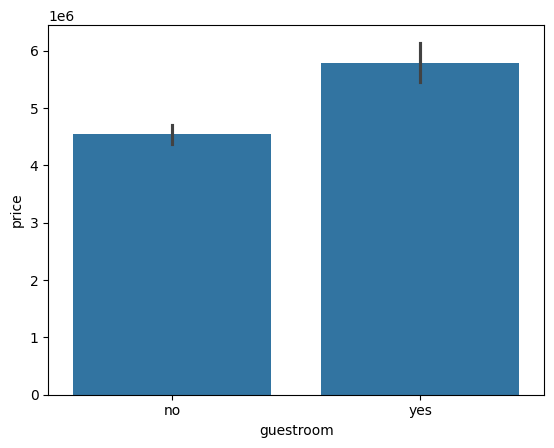

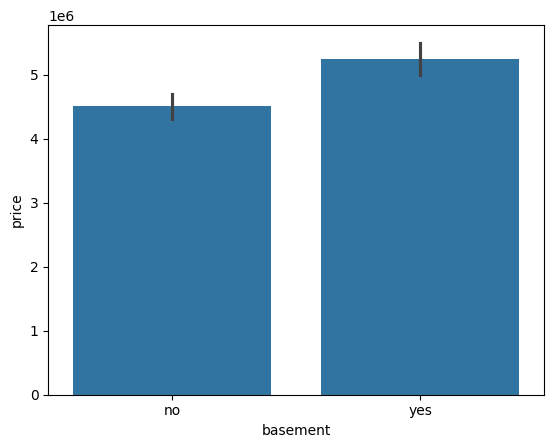

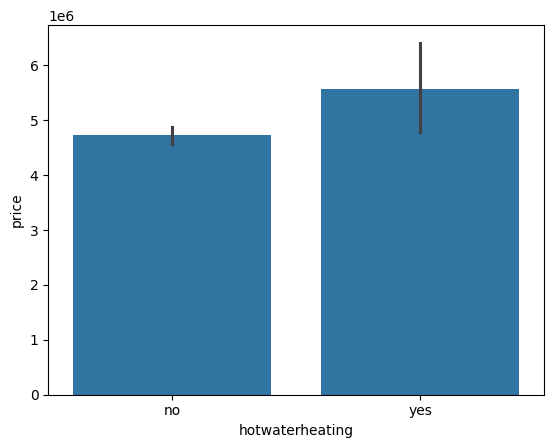

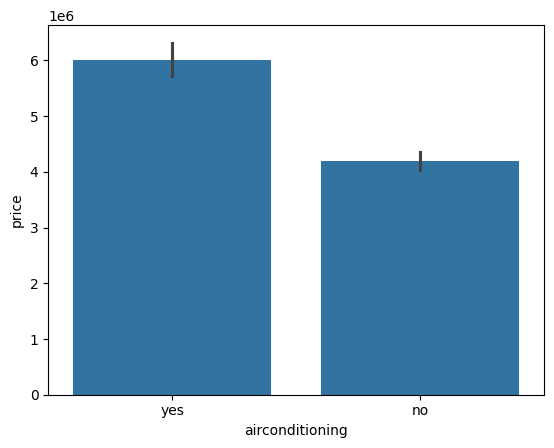

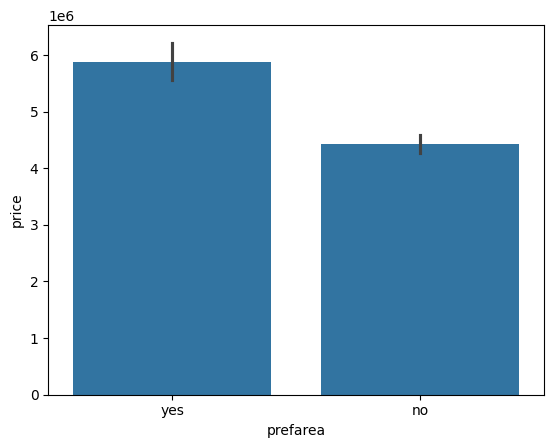

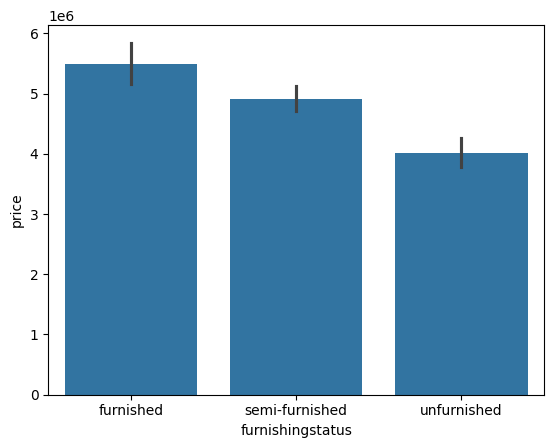

In [222]:
for i in df.select_dtypes(include='object').columns:
    sns.barplot(data=df,x=i,y='price')
    plt.show()

In [223]:
features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning' , 'prefarea'] 

for feature in features:
    df[feature] = df[feature].map({'yes':1, 'no':0})

In [224]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [225]:
df['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [226]:
df['furnishingstatus'] = df['furnishingstatus'].str.lower().str.strip()
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
})


In [227]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2


In [228]:
X = df.drop(['price'], axis=1)
y_true = df['price']

In [229]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.2, random_state=42)

In [230]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1,0,0,0,1,1,0,2
93,7200,3,2,1,1,0,1,0,1,3,0,1
335,3816,2,1,1,1,0,1,0,1,2,0,2
412,2610,3,1,2,1,0,1,0,0,0,1,0
471,3750,3,1,2,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,0
106,5450,4,2,1,1,0,1,0,1,0,1,1
270,4500,3,2,3,1,0,0,1,0,1,0,2
435,4040,2,1,1,1,0,0,0,0,0,0,0


In [231]:
from sklearn.preprocessing import StandardScaler

In [232]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [233]:
lr_model = LinearRegression()

In [234]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [235]:
print(lr_model.coef_)
print(lr_model.intercept_)

[2.35848772e+02 7.85744924e+04 1.09711727e+06 4.06223164e+05
 3.66824192e+05 2.33146766e+05 3.93159779e+05 6.87881311e+05
 7.85550579e+05 2.25756514e+05 6.29901661e+05 2.10397118e+05]
-127711.16739244014


In [236]:
y_train_pred = lr_model.predict(X_train)

In [237]:
print("Root Mean Squared Error: ", mean_squared_error(y_train, y_train_pred)**0.5)
print("R2 score: ", r2_score(y_train, y_train_pred))

Root Mean Squared Error:  984836.4426128389
R2 score:  0.6854429472843788


In [238]:
y_pred = lr_model.predict(X_test)

In [239]:
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred)**0.5)
print("R2 score: ", r2_score(y_test, y_pred))

Mean Squared Error:  1331071.4167895105
R2 score:  0.6494754192267804


In [240]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,0,0,1,0,0,1,0,0
77,6500,3,2,3,1,0,0,0,1,0,1,2
360,4040,2,1,1,1,0,0,0,0,0,0,1
90,5000,3,1,2,1,0,0,0,1,0,0,1
493,3960,3,1,1,1,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,1
357,6930,4,1,2,0,0,0,0,0,1,0,2
39,6000,4,2,4,1,0,0,0,1,1,0,1
54,6000,3,2,2,1,1,0,0,1,1,0,1


In [241]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [242]:
Y_pred = lr_model.predict([[6100, 3, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2]])

Y_pred

c:\Users\Rafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6409340.41089671])

In [246]:
area = float(input("Enter area: "))

beadrooms = int(input("Enter bedrooms: "))

bathrooms = int(input("Enter bathrooms: "))

stories = int(input("Enter stories: "))

mainroad = int(input("Main road? (0 = No, 1 = Yes): "))

guestroom = int(input("Guest room? (0 = No, 1 = Yes): "))

basement = int(input("Basement? (0 = No, 1 = Yes): "))

hotwaterheating = int(input("Hot water heating? (0 = No, 1 = Yes): "))

airconditioning = int(input("Air conditioning? (0 = No, 1 = Yes): "))

parking = int(input("Parking spaces: "))

prefarea = int(input("Preferred area? (0 = No, 1 = Yes): "))

furnishingstatus = int(input(
    "Furnishing status (0 = unfurnished, 1 = semi-furnished, 2 = furnished): "
))


price_pred = lr_model.predict([[area, beadrooms, bathrooms, stories,mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]])

print('Predicted price: ', price_pred[0])

Predicted price:  10975204.597400695


c:\Users\Rafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [247]:
joblib.dump(lr_model, 'House_price_prediction_model.pkl')
joblib.dump(scalar, 'scalar.pkl')

['scalar.pkl']